In [43]:
import torch 
import torchvision 
from torch import nn
from torch import optim
import torch.nn.functional as F
from math import prod
from matplotlib import pyplot as plt
import numpy as np

In [51]:
batch_size = 512
lr = 2e-4
latent_dim = 128
n_epochs = 100
device = 'cuda' if torch.cuda.is_available() else 'cpu'

to_numpy = lambda x: x.cpu().detach().numpy()

In [52]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
    ]
)
train_dataset = torchvision.datasets.CIFAR10(
    "CIFAR",
    train=True,
    download=True,
    transform=transform,
)
test_dataset = torchvision.datasets.CIFAR10(
    "CIFAR",
    train=False,
    download=True,
    transform=transform,
)
trainloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
testloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True
)

labels = train_dataset.classes

In [53]:
class ConvNeXtBlock(nn.Module):
    def __init__(self, input_size, num_channels, act=nn.GELU):
        super().__init__()
        self.conv1 = nn.Conv2d(num_channels, num_channels, kernel_size=3, stride=1, padding='same', groups=num_channels)
        self.conv2 = nn.Conv2d(num_channels, num_channels * 4, kernel_size=1, stride=1, padding='same')
        self.conv3 = nn.Conv2d(num_channels * 4, num_channels, kernel_size=1, stride=1, padding='same')
        self.layer_norm = nn.LayerNorm((num_channels, input_size, input_size))
        self.act = act()

    def forward(self, x):
        x_skip = x
        x = self.conv1(x)
        x = self.layer_norm(x)
        x = self.act(self.conv2(x))
        x = self.conv3(x) + x_skip
        return x
    
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_hidden=1, act=nn.GELU):
        super().__init__()
        self.layers = nn.Sequential()
        self.layers.append(nn.Linear(input_size, hidden_size))
        self.layers.append(act())
        for _ in range(num_hidden):
            self.layers.append(nn.Linear(hidden_size, hidden_size))
            self.layers.append(act())
        self.layers.append(nn.Linear(hidden_size, output_size))
    
    def forward(self, x):
        return self.layers(x)
    
class Encoder(nn.Module):
    def __init__(self, image_size=32, image_channels=3, conv_channels=[32, 64, 128], num_convs=[3, 3, 3], act=nn.GELU):
        super().__init__()
        convs = []
        convs.append(nn.Conv2d(image_channels, conv_channels[0], 7, padding=3, stride=1))
        convs.append(act())
        convs.append(ConvNeXtBlock(image_size, conv_channels[0]))
        convs.append(act())
        curr_size = image_size
        for i in range(len(conv_channels)):
            convs.append(nn.Conv2d(conv_channels[i], conv_channels[i], 3, padding=1, stride=2))
            curr_size = curr_size // 2
            for _ in range(num_convs[i]):
                convs.append(ConvNeXtBlock(curr_size, conv_channels[i]))
            if i < len(conv_channels) - 1:
                convs.append(nn.Conv2d(conv_channels[i], conv_channels[i + 1], 3, padding=1, stride=1))
                convs.append(act())
        self.convs = nn.ModuleList(convs)
        self.conv_shape = (conv_channels[-1], curr_size, curr_size)
        self.mlp = MLP(prod(self.conv_shape), latent_dim, 256, 0, act=act)
    
    def forward(self, x):
        for i in range(len(self.convs)):
            x = self.convs[i](x)
        x = x.flatten(1)
        x = self.mlp(x)
        return x
    
class Decoder(nn.Module):
    def __init__(self, conv_shape,  image_size=32, image_channels=3, conv_channels=[128, 64, 32], num_convs=[3, 3, 3], act=nn.GELU):
        super().__init__()
        convs_t = []
        self.conv_shape = conv_shape
        self.mlp = MLP(latent_dim, prod(conv_shape), 256, 0, act=act)
        curr_size = conv_shape[-1]
        for i in range(len(conv_channels)):
            for _ in range(num_convs[i]):
                convs_t.append(ConvNeXtBlock(curr_size, conv_channels[i]))
            convs_t.append(nn.ConvTranspose2d(conv_channels[i], conv_channels[i + 1] if i < len(conv_channels) - 1 else image_channels, 2, stride=2))
            convs_t.append(act())
            curr_size *= 2
        convs_t.append(ConvNeXtBlock(image_size, image_channels))
        convs_t.append(ConvNeXtBlock(image_size, image_channels))
        convs_t.append(nn.Sigmoid())
        self.convs_t = nn.ModuleList(convs_t)
    
    def forward(self, x):
        x = self.mlp(x)
        x = x.reshape(-1, *self.conv_shape)
        for i in range(len(self.convs_t)):
            x = self.convs_t[i](x)
        return x

$L_{\theta}(x) = \Vert f_{\theta}(x) - x \Vert^2 + \lambda \sum_{i} |\theta_i|
$

In [64]:
class AutoEncoder(nn.Module):
    def __init__(self, image_size=32, image_channels=3, conv_channels=[16, 64], num_convs=[3, 3], l1_penalty=0):
        super().__init__()
        self.encoder = Encoder(image_size, image_channels, conv_channels, num_convs)
        self.decoder = Decoder(self.encoder.conv_shape, image_size, image_channels, conv_channels[::-1], num_convs[::-1])
        self.loss = nn.BCELoss()
        self.penalty = l1_penalty
        
    def compute_latent(self, x):
        return self.encoder(x)
    
    def from_latent(self, latent):
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def reconstruction(self, x):
        latent = self.compute_latent(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def compute_loss(self, x):
        latent = self.compute_latent(x)
        reconstructed = self.from_latent(latent)
        loss = self.loss(reconstructed, x) + torch.sum(torch.abs(latent), -1).mean() * self.penalty
        return loss

In [55]:
def train_autoencoder(autoencoder, dataset, opt, epochs=n_epochs):
    def train_sample(autoencoder, opt, x):
        loss = autoencoder.compute_loss(x)
        loss.backward()
        opt.step()
        opt.zero_grad()
        return loss
    
    losses = []
    for epoch in range(1, epochs + 1):
        epoch_losses = []
        for x, _ in dataset:
            loss = train_sample(autoencoder, opt, x.to(device))
            epoch_losses.append(to_numpy(loss))
        losses.append(np.mean(epoch_losses))
        if epoch % 10 == 0:
            print(f'Epoch: {epoch}, Loss: {np.mean(epoch_losses)}')
    return autoencoder, losses
    

In [56]:
basic_autoencoder = AutoEncoder().to(device)
opt = optim.AdamW(basic_autoencoder.parameters(), lr)

Epoch: 10, Loss: 0.5757536292076111
Epoch: 20, Loss: 0.5693703293800354
Epoch: 30, Loss: 0.5658363699913025
Epoch: 40, Loss: 0.5640383362770081
Epoch: 50, Loss: 0.5628586411476135
Epoch: 60, Loss: 0.5620591044425964
Epoch: 70, Loss: 0.5613608956336975
Epoch: 80, Loss: 0.5607081055641174
Epoch: 90, Loss: 0.5602140426635742
Epoch: 100, Loss: 0.5598708987236023


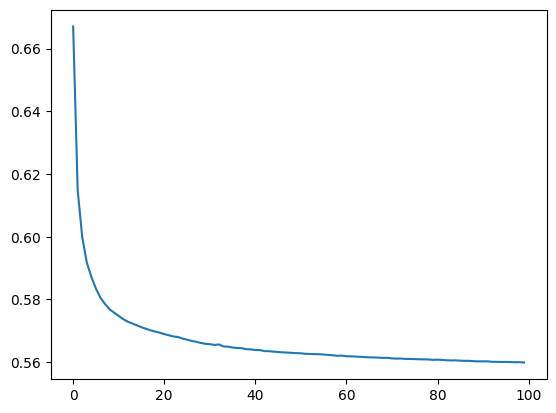

In [57]:
basic_autoencoder, losses = train_autoencoder(basic_autoencoder, trainloader, opt)
plt.plot(losses)

In [58]:
x_temp, y_temp = next(iter(trainloader))
x_pred = basic_autoencoder.reconstruction(x_temp.to(device))

In [59]:
def plot_ae_results(x_original, x_pred, x_class, num=8, figwidth=20, figheight=4):
    f, axs = plt.subplots(2, num)
    f.set_figheight(figheight)
    f.set_figwidth(figwidth)
    for i in range(num):
        axs[0, i].set_title(labels[x_class[i]])
        axs[0, i].imshow(to_numpy(x_original[i]).transpose(1, 2, 0))
        axs[0, i].axis('off')
        axs[1, i].imshow(to_numpy(x_pred[i]).transpose(1, 2, 0))
        axs[1, i].axis('off')

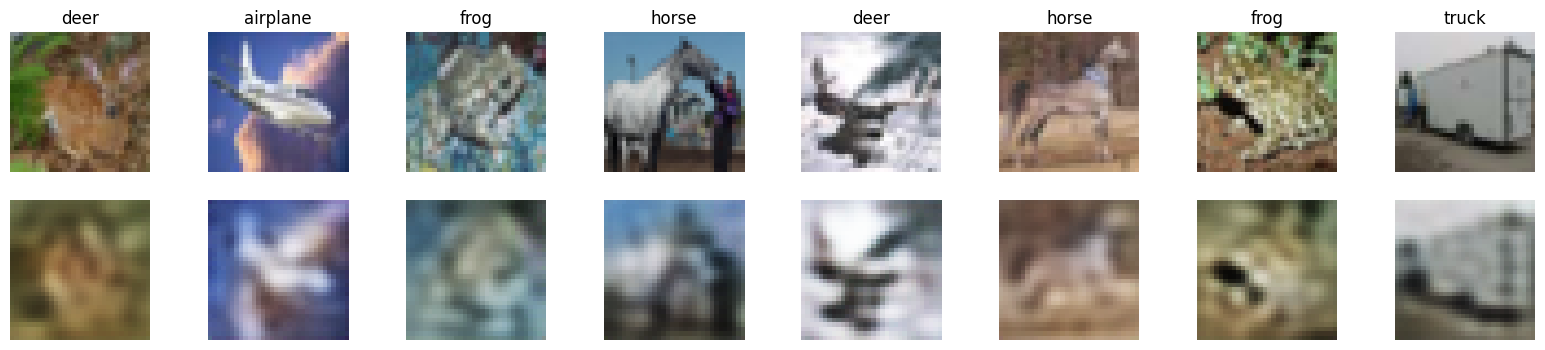

In [60]:
plot_ae_results(x_temp, x_pred, y_temp)

Epoch: 10, Loss: 0.5942792892456055
Epoch: 20, Loss: 0.5818531513214111
Epoch: 30, Loss: 0.5774785876274109
Epoch: 40, Loss: 0.5749249458312988
Epoch: 50, Loss: 0.5705855488777161
Epoch: 60, Loss: 0.5682297348976135
Epoch: 70, Loss: 0.5663655996322632
Epoch: 80, Loss: 0.5652263164520264
Epoch: 90, Loss: 0.5645108222961426
Epoch: 100, Loss: 0.5637794137001038
Epoch: 110, Loss: 0.5632699728012085
Epoch: 120, Loss: 0.5627729296684265
Epoch: 130, Loss: 0.5630879998207092
Epoch: 140, Loss: 0.562676191329956
Epoch: 150, Loss: 0.5623548626899719
Epoch: 160, Loss: 0.5620742440223694
Epoch: 170, Loss: 0.5618512630462646
Epoch: 180, Loss: 0.5616165399551392
Epoch: 190, Loss: 0.5615917444229126
Epoch: 200, Loss: 0.5614135265350342
Epoch: 210, Loss: 0.5612567067146301
Epoch: 220, Loss: 0.5610714554786682
Epoch: 230, Loss: 0.560993492603302
Epoch: 240, Loss: 0.5612858533859253
Epoch: 250, Loss: 0.5608893036842346


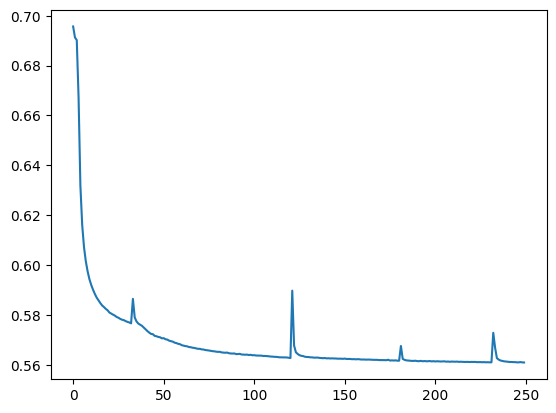

In [ ]:
sparse_autoencoder = AutoEncoder(l1_penalty=1e-3).to(device)
opt = optim.AdamW(sparse_autoencoder.parameters(), 1e-4)

sparse_autoencoder, losses = train_autoencoder(sparse_autoencoder, trainloader, opt, epochs=250)
plt.plot(losses)

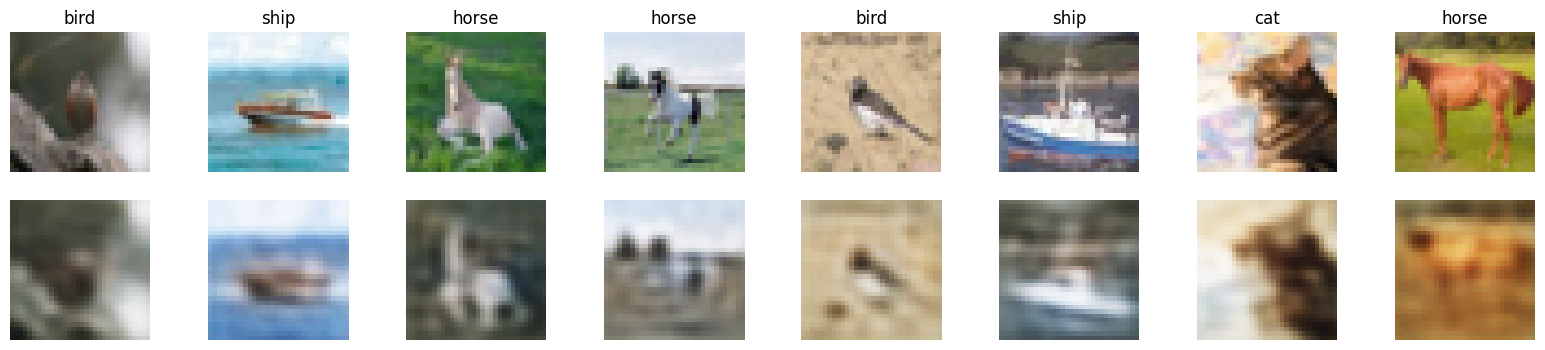

In [67]:
x_temp, y_temp = next(iter(trainloader))
x_pred = sparse_autoencoder.reconstruction(x_temp.to(device))

plot_ae_results(x_temp, x_pred, y_temp)

### Trying to visualize the difference between the vanilla autoencoder and the sparse one

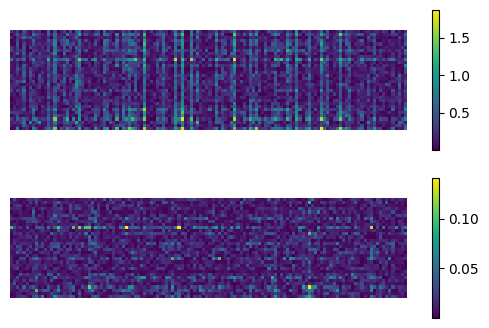

In [71]:
basic_latent = basic_autoencoder.compute_latent(x_temp.to(device))
sparse_latent = sparse_autoencoder.compute_latent(x_temp.to(device))

f, axs = plt.subplots(2)
f.set_figheight(4)
axs[0].axis('off')
im = axs[0].imshow(to_numpy(basic_latent[:32].abs()))
f.colorbar(im)
axs[1].axis('off')
im = axs[1].imshow(to_numpy(sparse_latent[:32].abs()))
f.colorbar(im)

In [69]:
class VanillaVAE(AutoEncoder):
    def __init__(self, image_size=32, image_channels=3, conv_channels=[16, 64], num_convs=[3, 3]):
        super().__init__()
        self.encoder = Encoder(image_size, image_channels, conv_channels, num_convs)
        self.mu = MLP(latent_dim, latent_dim, 0)
        self.sigma = MLP(latent_dim, latent_dim, 0)
        self.decoder = Decoder(self.encoder.conv_shape, image_size, image_channels, conv_channels[::-1], num_convs[::-1])
        
    def compute_latent(self, x):
        x = self.encoder(x)
        mu = self.mu(x)
        sigma = self.sigma(x)
        return mu, sigma
    
    def from_latent(self, latent):
        mu, sigma = latent
        z = torch.randn() * sigma + mu
        reconstructed = self.decoder(z)
        return reconstructed
    
    def reconstruction(self, x):
        latent = self.compute_latent(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def compute_loss(self, x):
        latent = self.compute_latent(x)
        reconstructed = self.from_latent(latent)
        loss = self.loss(reconstructed, x) + torch.norm(latent, 1, -1).mean() * self.penalty
        return loss